In [1]:
pip install lightgbm


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install xgboost

  Using cached xgboost-2.1.4-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ----

ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "c:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
  File "c:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
  File "c:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 98, in read
    data: bytes = self.__fp.read(amt)
  File "c:\Users\HP\AppData\Local\Programs\Python\Python39\lib\http\client.py", line 458, in read
    n = self.readinto(b)
  File "c:\Users\HP\AppData\Local\Programs\Python\Python39\lib\http\client.py", line 502, in readinto
    n = sel

In [9]:
import sys
print(sys.executable)


c:\Users\HP\AppData\Local\Programs\Python\Python39\python.exe


In [14]:
pip install --upgrade pip

  Using cached pip-25.1.1-py3-none-any.whl.metadata (3.6 kB)
Using cached pip-25.1.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 23.3.2
    Uninstalling pip-23.3.2:
      Successfully uninstalled pip-23.3.2
Note: you may need to restart the kernel to use updated packages.


In [15]:
pip install xgboost

  Using cached xgboost-2.1.4-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ----

In [5]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


C:\Users\HP\AppData\Local\Temp\ipykernel_11732\530876397.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# Load datasets
try:
    df_train = pd.read_csv('Titanic_train.csv')
    df_test = pd.read_csv('Titanic_test.csv')
except FileNotFoundError:
    print("Error: Could not find the datasets. Please ensure the file paths are correct.")
    exit()

In [3]:
# Check for missing values
print("Missing values in training data:")
print(df_train.isnull().sum())
print("Missing values in testing data:")
print(df_test.isnull().sum())

Missing values in training data:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Missing values in testing data:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


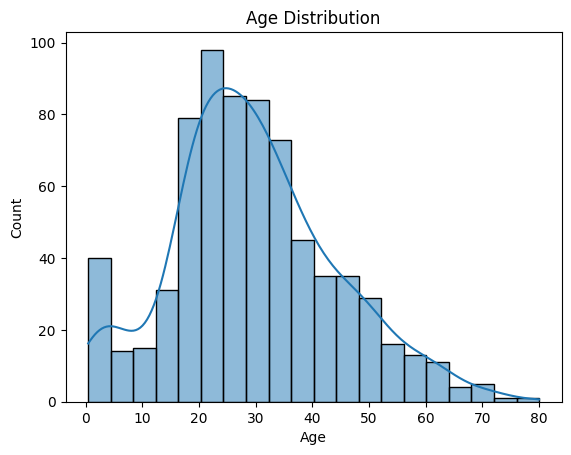

In [4]:
#Visualize distributions

import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for Age
sns.histplot(df_train['Age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.show()

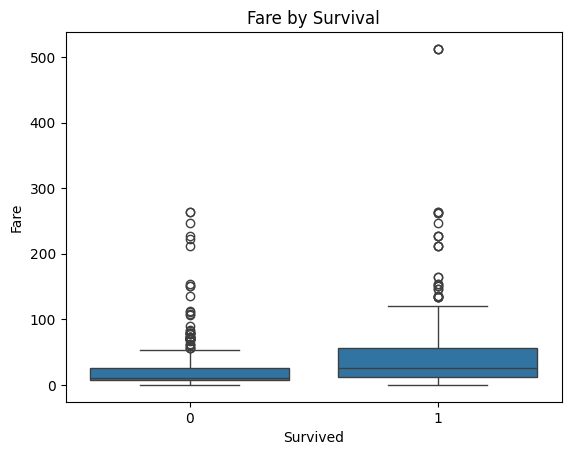

In [5]:
# Boxplot for Fare
sns.boxplot(x='Survived', y='Fare', data=df_train)
plt.title('Fare by Survival')
plt.show()

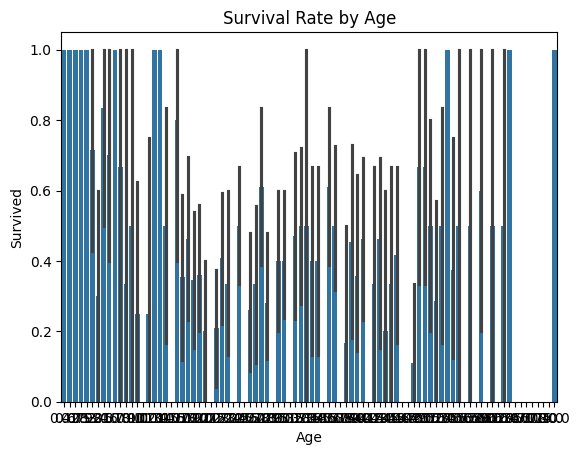

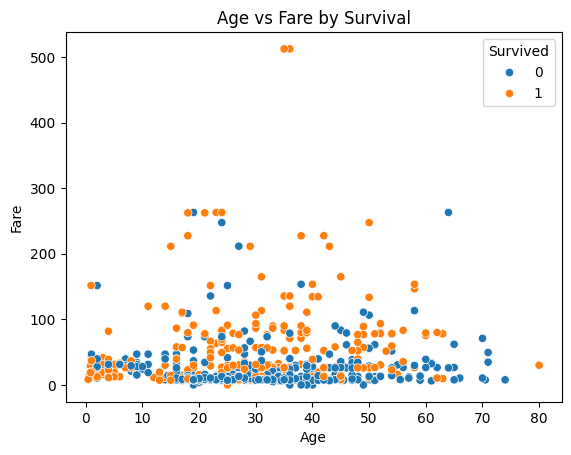

In [6]:
#Visualize feature relationships

# Bar plot: Survival by Sex
sns.barplot(x='Age', y='Survived', data=df_train)
plt.title('Survival Rate by Age')
plt.show()

# Scatter plot: Age vs Fare colored by Survival
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df_train)
plt.title('Age vs Fare by Survival')
plt.show()


In [7]:
# Age and Fare: fill with median
df_train['Age'].fillna(df_train['Age'].median(), inplace=True)
df_test['Age'].fillna(df_test['Age'].median(), inplace=True)
df_test['Fare'].fillna(df_test['Fare'].median(), inplace=True)




C:\Users\HP\AppData\Local\Temp\ipykernel_11732\2955180672.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['Age'].fillna(df_train['Age'].median(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_11732\2955180672.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


In [9]:
# Embarked: fill with mode
df_train['Embarked'].fillna(df_train['Embarked'].mode()[0], inplace=True)



C:\Users\HP\AppData\Local\Temp\ipykernel_11732\2314250296.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['Embarked'].fillna(df_train['Embarked'].mode()[0], inplace=True)


In [10]:
# Cabin: create binary feature, drop original
df_train['HasCabin'] = df_train['Cabin'].notnull().astype(int)
df_test['HasCabin'] = df_test['Cabin'].notnull().astype(int)
df_train.drop('Cabin', axis=1, inplace=True)
df_test.drop('Cabin', axis=1, inplace=True)

In [13]:
# One-hot encoding for categorical features
df_train = pd.get_dummies(df_train, columns=['Sex', 'Embarked', 'Pclass'])
df_test = pd.get_dummies(df_test, columns=['Sex', 'Embarked', 'Pclass'])


In [15]:
#Prepare Data for Modeling
#Define features and target

drop_cols = ['Survived', 'Name', 'Ticket', 'PassengerId']
X = df_train.drop(drop_cols, axis=1)
y = df_train['Survived']


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# LightGBM
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(random_state=42)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_val)


[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000422 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 203
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [19]:
#XGBoost
from xgboost import XGBClassifier

xgbm = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgbm.fit(X_train, y_train)
y_pred_xgbm = xgbm.predict(X_val)


c:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:19:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [20]:
#Evaluate Models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred, model_name):
    print(f"{model_name} Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"{model_name} Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"{model_name} Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"{model_name} F1-score: {f1_score(y_true, y_pred):.4f}\n")

evaluate(y_val, y_pred_lgbm, "LightGBM")
evaluate(y_val, y_pred_xgbm, "XGBoost")


LightGBM Accuracy: 0.8101
LightGBM Precision: 0.7632
LightGBM Recall: 0.7838
LightGBM F1-score: 0.7733

XGBoost Accuracy: 0.8101
XGBoost Precision: 0.7778
XGBoost Recall: 0.7568
XGBoost F1-score: 0.7671



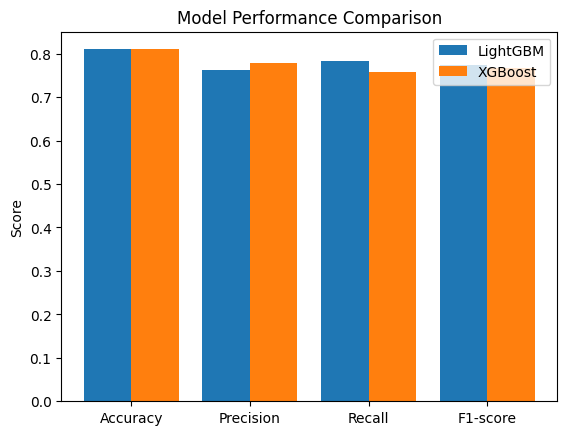

In [22]:
#Hyperparameter Tuning

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
lgbm_scores = [accuracy_score(y_val, y_pred_lgbm), precision_score(y_val, y_pred_lgbm), recall_score(y_val, y_pred_lgbm), f1_score(y_val, y_pred_lgbm)]
xgbm_scores = [accuracy_score(y_val, y_pred_xgbm), precision_score(y_val, y_pred_xgbm), recall_score(y_val, y_pred_xgbm), f1_score(y_val, y_pred_xgbm)]

import numpy as np

x = np.arange(len(metrics))
plt.bar(x - 0.2, lgbm_scores, width=0.4, label='LightGBM')
plt.bar(x + 0.2, xgbm_scores, width=0.4, label='XGBoost')
plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()
